## Description of Program
- program:    ncoda_08bv1_ExploreBlocks
- task:       Explore Blocks by Housing Unit Estimate File
- See github commits for description of program updates
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

## Setup Python Environment

In [2]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs
from pyncoda.ncoda_00e_geoutilities import df2gdf_WKTgeometry


In [3]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow
from pyncoda.ncoda_08a_check_block import BlockValidationChecker


In [4]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Mon May 25 14:09:48 2026 Eastern Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [5]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

### Explore Housing Unit Estimate File
The Housing Unite Estimate files have details on how each building is assigned a number of housing units. These housing units are used to generate the number of address points within the block. The housing units take into account the building archetype, the building square footage, and the number of housing units reported by the decennial census.

The Housing Unit Estimate File has the following variables:



| Variable | Label | Description (based on source code) |
|---|---|---|
| blockBLOCKID10_str / blockBLOCKID20_str | Census Block ID (string) | Block identifier joined from census block-place-puma data and building representative points. Missing values are set to `B999999999999999` (`No Block ID`). |
| fd_id_bid | Building Unique ID | Building identifier from NSI/building inventory (`bldg_uniqueid`) used to track structure-level estimates. |
| blockplaceNAME10 / blockplaceNAME20 | Place Name | Place name from census block join (`placename_var`). Filled with `Unincorporated` when missing; set to `No Block ID` when block id is missing. |
| occtype | Building Archetype / Occupancy Type | Building archetype field (`archetype_var`) used to classify residential structures and assign initial unit estimates. |
| sqft | Building Area (sq ft) | Building area field (`building_area_var`) used to screen small buildings and distribute additional units in round 2. |
| huestimate | Final Housing Unit Estimate | Final per-building estimated housing units after 3-round adjustment process (`residentialAP2v2`, then round-3 increment rules). |
| residential | Residential Indicator | Binary flag where 1 indicates a structure is treated as residential (initially based on round-1 estimated units). |
| apcount | Expected Housing Unit Address Points (block) | Block-level expected count from HUI (`count(huid)` by block), merged onto each building in that block. |
| bldgcount | Building Count (row-level) | Constant `1` per building record; used for block-level aggregation/diagnostics. |
| residentialAP1 | Round 1 Residential Address Point Estimate | Initial per-building estimate from residential archetype rules (or `residential_unit_var` when provided), adjusted by area cutoffs. |
| residentialAP1_sum | Round 1 Estimated Units Sum by Block | Sum of `residentialAP1` within block; used to compare against expected `apcount`. |
| bldgcount1_sum | Round 1 Building Count Sum by Block | Sum of `bldgcount` by block in round 1 diagnostics. |
| DiffCount1 | Round 1 Difference (Expected - Estimated) | `apcount - residentialAP1_sum`; block-level shortfall/surplus after round 1. |
| ErrorCheck1_int | Round 1 Error Code | Integer categorical code from block comparison logic (HU vs estimated AP and building presence). |
| residentialAP2 | Round 2 Distributed Adjustment | Fractional building-level allocation of `DiffCount1` based on each building's residential floor area share in the block. |
| residentialAP2v2 | Round 2 Updated Building Estimate | Rounded `residentialAP2` plus `residentialAP1`, with overrides for specific round-1 error states. |
| residentialAP2v2_sum | Round 2 Estimated Units Sum by Block | Sum of `residentialAP2v2` by block for round-2 diagnostics. |
| bldgcountv2_sum | Round 2 Building Count Sum by Block | Sum of buildings by block in round-2 diagnostics. |
| DiffCount2 | Round 2 Difference (Expected - Estimated) | `apcount - residentialAP2v2_sum`; block-level shortfall/surplus after round 2. |
| ErrorCheck2_int | Round 2 Error Code | Integer categorical code from second-round HU vs AP comparison. |
| residentialAP2v3_sum | Round 3 Estimated Units Sum by Block | Sum of final `huestimate` by block (named as round-3 sum column). |
| bldgcountv3_sum | Round 3 Building Count Sum by Block | Sum of buildings by block in round-3 diagnostics. |
| DiffCount3 | Round 3 Difference (Expected - Estimated) | `apcount - residentialAP2v3_sum`; final block-level shortfall/surplus. |
| ErrorCheck3_int | Round 3 Error Code | Integer categorical code from final HU vs AP comparison. |
| d_sf | Single-Family Dummy | `1` if `huestimate == 1` and building id is present; `0` if `huestimate > 1` and building id is present. |


Error code values for `ErrorCheck1_int`, `ErrorCheck2_int`, `ErrorCheck3_int` (from `block_error_check_addresspoints`):

`0` HU missing; `1` HU=0; `2` HU=AP; `3` HU<AP; `4` HU>AP; `5` HU>0, AP=0; `6` HU>0, AP missing with buildings present; `7` HU>0, AP missing; `8` HU>0, building count missing; `9` HU>0, building count=0; `10` HU=0, building count missing.

Source used: `pyncoda/ncoda_07c_generate_addpt.py` and `pyncoda/ncoda_02d_addresspoint.py`, validated against `OutputData/huest_v2-2-0_Hayward_CA_NSI_2010_NSI.csv` and `OutputData/huest_v2-2-0_Hayward_CA_NSI_2020_NSI.csv`.

## Obtain Data for Exploration

In [6]:
tabblock_dict_gdf = {}

In [7]:
tabblock_df = pd.read_csv("OutputData\\tl_2010_Hayward_CA_NSI_tabblockplacepuma10EPSG4269.csv")
tabblock_dict_gdf['2010'] = df2gdf_WKTgeometry(
    tabblock_df,
    projection="epsg:4269",
    reproject="epsg:4326",
    geometryvar="geometry"
)

Converting geometry to Geodataframe


In [8]:
tabblock_df = pd.read_csv("OutputData\\tl_2020_Hayward_CA_NSI_tabblockplacepuma20EPSG4269.csv")
tabblock_dict_gdf['2020'] = df2gdf_WKTgeometry(
    tabblock_df,
    projection="epsg:4269",
    reproject="epsg:4326",
    geometryvar="geometry"
)

Converting geometry to Geodataframe


In [9]:
huest_df_dict = {}

In [10]:
huest_path_2010 = r"OutputData\huest_v2-2-0_Hayward_CA_NSI_2010_NSI.csv"
huest_path_2020 = r"OutputData\huest_v2-2-0_Hayward_CA_NSI_2020_NSI.csv"

huest_df_dict['2010'] = pd.read_csv(huest_path_2010)
huest_df_dict['2020'] = pd.read_csv(huest_path_2020)

In [11]:
hua_df_dict = {}
hua_path_2010 = r"OutputData\hua_v2-2-0_Hayward_CA_NSI_2010_rs9876_NSI.csv"
hua_path_2020 = r"OutputData\hua_v2-2-0_Hayward_CA_NSI_2020_rs9876_NSI.csv"

hua_df_dict['2010'] = pd.read_csv(hua_path_2010)
hua_df_dict['2020'] = pd.read_csv(hua_path_2020)

In [12]:
nsi_path = r"OutputData\00_SourceData\nsi_sec_usace_army_mil\nsi_01av1_hua_06001.shp"
nsi_gdf = gpd.read_file(nsi_path)

addpt_df_dict = {}
addpt_path_2010 = r"OutputData\addpt_v2-2-0_Hayward_CA_NSI_2010_NSI.csv"
addpt_path_2020 = r"OutputData\addpt_v2-2-0_Hayward_CA_NSI_2020_NSI.csv"

addpt_df_dict['2010'] = pd.read_csv(addpt_path_2010)
addpt_df_dict['2020'] = pd.read_csv(addpt_path_2020)

## Clean Data files

In [13]:
# create a blockid based on BLOCKID10_str minus B
tabblock_dict_gdf['2010']['blockid'] = tabblock_dict_gdf['2010']['BLOCKID10_str'].str.replace('B', '')
tabblock_dict_gdf['2020']['blockid'] = tabblock_dict_gdf['2020']['BLOCKID20_str'].str.replace('B', '')

In [14]:
hua_gdf_dict = {}

from shapely.geometry import Point

def add_wkt_geometry_from_xy(df, x_col, y_col, geometry_col="geometry"):
    """
    Create a WKT geometry column from x/y coordinate columns.

    Notes:
    - For geographic CRS (e.g., EPSG:4326 or EPSG:4269), x is longitude and y is latitude.
    - For projected CRS (e.g., UTM), x/y are projected coordinates (typically easting/northing).
    """
    out_df = df.copy(deep=True)
    out_df[x_col] = pd.to_numeric(out_df[x_col], errors="coerce")
    out_df[y_col] = pd.to_numeric(out_df[y_col], errors="coerce")

    out_df[geometry_col] = [
        Point(x, y).wkt if pd.notna(x) and pd.notna(y) else None
        for x, y in zip(out_df[x_col], out_df[y_col])
    ]
    return out_df

# convert x/y coordinates to WKT geometry, then to GeoDataFrame
hua_df_with_geom_2010 = add_wkt_geometry_from_xy(
    hua_df_dict['2010'],
    x_col='x',
    y_col='y',
    geometry_col='geometry'
)

hua_gdf_dict['2010'] = df2gdf_WKTgeometry(
    hua_df_with_geom_2010,
    projection="epsg:4269",
    reproject="epsg:4269",
    geometryvar="geometry"
)

Converting geometry to Geodataframe


In [15]:
# convert x/y coordinates to WKT geometry, then to GeoDataFrame
hua_df_with_geom_2020 = add_wkt_geometry_from_xy(
    hua_df_dict['2020'],
    x_col='x',
    y_col='y',
    geometry_col='geometry'
)

hua_gdf_dict['2020'] = df2gdf_WKTgeometry(
    hua_df_with_geom_2020,
    projection="epsg:4269",
    reproject="epsg:4269",
    geometryvar="geometry"
)

Converting geometry to Geodataframe


### Add Equity Flags to HUA File

In [16]:
# Flag housing units that are renters
def flag_renter_units(df, tenure_col='ownershp', renter_value=2):
    """
    Add a boolean column 'renter' to the DataFrame based on tenure information.

    Parameters:
    - df: Input DataFrame containing housing unit data.
    - tenure_col: Name of the column that indicates tenure status (default 'tenure').
    - renter_value: The value in the tenure column that indicates a renter (default 'Renter').

    Returns:
    - DataFrame with an additional 'renter' column.
    """
    out_df = df.copy(deep=True)
    out_df['renter'] = out_df[tenure_col] == renter_value

    # convert from boolean to binary
    out_df['renter'] = out_df['renter'].astype(int)

    return out_df

# Flag housing units with low income (use less than median income as a proxy for low income)
def flag_income_units(df, income_col='randincome', income_quantile=0.5, below = True):
    """
    Add a boolean column 'income_{quantile}' to the DataFrame based on income information.

    Parameters:
    - df: Input DataFrame containing housing unit data.
    - income_col: Name of the column that indicates income (default 'income').
    - income_quantile: The quantile of income to use as the threshold (default 0.5 for median).
    - below: Whether to flag units with income below the threshold (default True).

    Returns:
    - DataFrame with an additional 'low_income' column. 
    """
    out_df = df.copy(deep=True)
    income_level = out_df[income_col].quantile(income_quantile)
    print(f"Income level for quantile {income_quantile}: {income_level}")
    if below:
        out_df[f'income_{income_quantile}'] = out_df[income_col] < income_level
    else:
        out_df[f'income_{income_quantile}'] = out_df[income_col] > income_level
    # convert from boolean to binary
    out_df[f'income_{income_quantile}'] = out_df[f'income_{income_quantile}'].astype(int)
    return out_df

# Add renter flag to hua_gdf_dict for 2010 and 2020
hua_gdf_dict['2010'] = flag_renter_units(hua_gdf_dict['2010'], tenure_col='ownershp', renter_value=2)
hua_gdf_dict['2020'] = flag_renter_units(hua_gdf_dict['2020'], tenure_col='ownershp', renter_value=2)

# Add low income flag to hua_gdf_dict for 2010 and 2020
hua_gdf_dict['2010'] = flag_income_units(hua_gdf_dict['2010'], income_col='randincome', income_quantile=0.25, below=True)
hua_gdf_dict['2020'] = flag_income_units(hua_gdf_dict['2020'], income_col='randincome', income_quantile=0.25, below=True)

# Add high income flag to hua_gdf_dict for 2010 and 2020
hua_gdf_dict['2010'] = flag_income_units(hua_gdf_dict['2010'], income_col='randincome', income_quantile=0.75, below=False)
hua_gdf_dict['2020'] = flag_income_units(hua_gdf_dict['2020'], income_col='randincome', income_quantile=0.75, below=False)

# Add binary for low income renters
hua_gdf_dict['2010']['low_income_renter'] = hua_gdf_dict['2010']['renter'] & hua_gdf_dict['2010']['income_0.25']
hua_gdf_dict['2020']['low_income_renter'] = hua_gdf_dict['2020']['renter'] & hua_gdf_dict['2020']['income_0.25']

# Add binary for high income homeowners
hua_gdf_dict['2010']['high_income_homeowner'] = ~hua_gdf_dict['2010']['renter'] & hua_gdf_dict['2010']['income_0.75']
hua_gdf_dict['2020']['high_income_homeowner'] = ~hua_gdf_dict['2020']['renter'] & hua_gdf_dict['2020']['income_0.75']

Income level for quantile 0.25: 34302.0
Income level for quantile 0.25: 58737.75
Income level for quantile 0.75: 126711.25
Income level for quantile 0.75: 206332.25


In [17]:
# 
hua_gdf_dict['2010'][['huid','ownershp','randincome','renter', 'income_0.25', 'income_0.75', 'low_income_renter', 'high_income_homeowner']].head()

,huid,ownershp,randincome,renter,income_0.25,income_0.75,low_income_renter,high_income_homeowner
0,B060014001001007H0001,1.0,122331.0,0,0,0,0,0
1,B060014001001007H0002,1.0,249702.0,0,0,1,0,1
2,B060014001001007H0003,1.0,81115.0,0,0,0,0,0
3,B060014001001007H0004,1.0,185826.0,0,0,1,0,1
4,B060014001001007H0005,1.0,173579.0,0,0,1,0,1


In [18]:
# describe new variables
hua_gdf_dict['2010'][['ownershp','randincome','renter', 'income_0.25', 'income_0.75', 'low_income_renter', 'high_income_homeowner']].describe().T

,count,mean,std,min,25%,50%,75%,max
ownershp,545138.0,1.465746,0.498826,1.0,1.0,1.0,2.00,2.0
randincome,545138.0,88074.936124,66007.878325,0.0,34302.0,71405.0,126711.25,249999.0
renter,583472.0,0.435147,0.495777,0.0,0.0,0.0,1.00,1.0
income_0.25,583472.0,0.233572,0.423104,0.0,0.0,0.0,0.00,1.0
income_0.75,583472.0,0.233576,0.423106,0.0,0.0,0.0,0.00,1.0
low_income_renter,583472.0,0.138558,0.345486,0.0,0.0,0.0,0.00,1.0
high_income_homeowner,583472.0,0.160445,0.367018,0.0,0.0,0.0,0.00,1.0


In [19]:
hua_gdf_dict['2020'][['ownershp','randincome','renter', 'income_0.25', 'income_0.75', 'low_income_renter', 'high_income_homeowner']].describe().T

,count,mean,std,min,25%,50%,75%,max
ownershp,591636.0,1.481979,0.499676,1.0,1.00,1.0,2.00,2.0
randincome,591636.0,128042.051101,77686.798065,0.0,58737.75,122029.0,206332.25,249999.0
renter,625950.0,0.455557,0.498021,0.0,0.00,0.0,1.00,1.0
income_0.25,625950.0,0.236295,0.424806,0.0,0.00,0.0,0.00,1.0
income_0.75,625950.0,0.236295,0.424806,0.0,0.00,0.0,0.00,1.0
low_income_renter,625950.0,0.141120,0.348145,0.0,0.00,0.0,0.00,1.0
high_income_homeowner,625950.0,0.151549,0.358583,0.0,0.00,0.0,0.00,1.0


### Summarize low income renter and high income homeowner by block and tract

In [39]:
hua_block_agg_dict = {}
# aggregate block level counts of renters, low income renters, and high income homeowners
for yr in ['2010', '2020']:
    df = hua_gdf_dict[yr].groupby('blockid').agg({
        'huid': 'count',
        'randincome': 'count',
        'numprec': 'sum',
        'income_0.25': 'sum',
    'income_0.75': 'sum',
    'renter': 'sum',
    'low_income_renter': 'sum',
    'high_income_homeowner': 'sum'
    }).reset_index()
    # rename columns huid to hui_count and randincome to occupied_hui_count
    df = df.rename(columns={'huid': 'hui_count', 'randincome': 'occupied_hui_count'})
    # add percent of housing units that are renters, low income renters, and high income homeowners
    df['percent_renter'] = df['renter'] / df['occupied_hui_count']
    df['percent_low_income_renter'] = df['low_income_renter'] / df['occupied_hui_count']
    df['percent_high_income_homeowner'] = df['high_income_homeowner'] / df['occupied_hui_count']

    # convert blockid to string and add leading zeros to match BLOCKID10_str format
    df[f'BLOCKID{yr[2:4]}_str'] = 'B'+df['blockid'].astype(str).str.zfill(15)
    # move blockid string column to the front
    cols = df.columns.tolist()
    cols = [f'BLOCKID{yr[2:4]}_str'] + [col for col in cols if col != f'BLOCKID{yr[2:4]}_str']
    df = df[cols]

    # drop blockid column
    df = df.drop(columns=['blockid'])
    
    hua_block_agg_dict[yr] = df
hua_block_agg_dict['2010'].head()

,BLOCKID10_str,hui_count,occupied_hui_count,numprec,income_0.25,income_0.75,renter,low_income_renter,high_income_homeowner,percent_renter,percent_low_income_renter,percent_high_income_homeowner
0,B060014001001007,57,53,117,3,35,21,1,23,0.396226,0.018868,0.433962
1,B060014001001008,10,9,20,2,4,1,0,3,0.111111,0.000000,0.333333
2,B060014001001011,6,6,13,1,1,0,0,1,0.000000,0.000000,0.166667
3,B060014001001013,3,1,1,0,0,1,0,0,1.000000,0.000000,0.000000
4,B060014001001014,10,10,20,2,6,1,0,5,0.100000,0.000000,0.500000


In [40]:
hua_block_agg_dict['2020'].head()

,BLOCKID20_str,hui_count,occupied_hui_count,numprec,income_0.25,income_0.75,renter,low_income_renter,high_income_homeowner,percent_renter,percent_low_income_renter,percent_high_income_homeowner
0,B060014001001009,2,2,6,0,1,0,0,1,0.000000,0.000000,0.500000
1,B060014001001010,67,62,159,11,26,0,0,26,0.000000,0.000000,0.419355
2,B060014001001011,75,65,166,3,32,24,3,22,0.369231,0.046154,0.338462
3,B060014001001013,10,4,12,1,2,0,0,2,0.000000,0.000000,0.500000
4,B060014001001014,9,9,15,0,4,0,0,4,0.000000,0.000000,0.444444


### Add Diagnostic Variables to HU Estimate File

In [41]:
# Mean absolute error by block: mean(|assigned - expected|) across buildings in each block
for yr in ['2010', '2020']:
    block_col = f"blockBLOCKID{yr[2:4]}_str"
    df = huest_df_dict[yr].copy(deep=True)

    # Building-level absolute error between assigned and expected units
    df['abs_error_assigned_expected'] = (df['huestimate'] - df['residentialAP1']).abs()

    huest_df_dict[yr] = df

# Quick check
huest_df_dict['2010'][[
    'blockBLOCKID10_str','fd_id_bid','huestimate', 'residentialAP1',
    'abs_error_assigned_expected'
]].head()

,blockBLOCKID10_str,fd_id_bid,huestimate,residentialAP1,abs_error_assigned_expected
0,B060014001001000,nsi-474712228-849VVQJ4+7Q7-3-4-2-4,0.0,0.0,0.0
1,B060014001001000,nsi-474712229-849VVQJ5+72F-2-2-2-2,0.0,0.0,0.0
2,B060014001001000,nsi-474712230-849VVQJ4+7XV-2-2-2-2,0.0,0.0,0.0
3,B060014001001000,nsi-474712231-849VVQJ5+C39-7-6-7-5,0.0,0.0,0.0
4,B060014001001000,nsi-474712232-849VVQJ5+G57-2-2-1-3,0.0,0.0,0.0


In [42]:
huest_df_dict['2010'].columns

Index(['blockBLOCKID10_str', 'fd_id_bid', 'blockplaceNAME10', 'occtype',
       'sqft', 'huestimate', 'residential', 'apcount', 'bldgcount',
       'residentialAP1', 'residentialAP1_sum', 'bldgcount1_sum', 'DiffCount1',
       'ErrorCheck1_int', 'residentialAP2', 'residentialAP2v2',
       'residentialAP2v2_sum', 'bldgcountv2_sum', 'DiffCount2',
       'ErrorCheck2_int', 'residentialAP2v3_sum', 'bldgcountv3_sum',
       'DiffCount3', 'ErrorCheck3_int', 'd_sf', 'abs_error_assigned_expected'],
      dtype='object')

In [43]:
# Block-level summary table for each year
huest_block_summary_dict = {}

for yr in ['2010', '2020']:
    block_col = f"blockBLOCKID{yr[2:4]}_str"
    df = huest_df_dict[yr].copy(deep=True)

    # look at only if residential == 1
    df = df[df['residential'] == 1]

    huest_block_summary_dict[yr] = (
        df.groupby(block_col, as_index=False)
          .agg(
              huestimate=('huestimate', 'sum'),
              building_count=('fd_id_bid', 'count'),
              huexpected=('residentialAP1', 'sum'),
              total_sqfootage=('sqft', 'sum'),
              mean_abs_error_block=('abs_error_assigned_expected', 'mean')
          )
          .sort_values(block_col)
          .reset_index(drop=True)
    )

    # rename blockBLOCKID10_str = BLOCKID10_str
    huest_block_summary_dict[yr] = huest_block_summary_dict[yr].rename(columns={block_col: f'BLOCKID{yr[2:4]}_str'})
    print(f"Year {yr}: {huest_block_summary_dict[yr].shape[0]} blocks summarized")

    # add percent change between huestimate and huexpected
    huest_block_summary_dict[yr]['percent_change'] = (
        (huest_block_summary_dict[yr]['huestimate'] - huest_block_summary_dict[yr]['huexpected']) /
        huest_block_summary_dict[yr]['huexpected'].replace(0, np.nan)
    ) * 100

    # add square footage per unit
    huest_block_summary_dict[yr]['sqft_per_unit'] = (
        huest_block_summary_dict[yr]['total_sqfootage'] /
        huest_block_summary_dict[yr]['huestimate'].replace(0, np.nan)
    )

# Quick check
huest_block_summary_dict['2010'].head()

Year 2010: 14243 blocks summarized
Year 2020: 13066 blocks summarized


,BLOCKID10_str,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
0,B060014001001007,94.0,42,52.0,111462.625,1.0,80.769231,1185.772606
1,B060014001001008,10.0,10,10.0,27319.000,0.0,0.000000,2731.900000
2,B060014001001011,7.0,7,7.0,21742.000,0.0,0.000000,3106.000000
3,B060014001001013,5.0,5,5.0,11402.000,0.0,0.000000,2280.400000
4,B060014001001014,18.0,9,9.0,16849.000,1.0,100.000000,936.055556


In [44]:
huest_block_summary_dict['2020'].head()

,BLOCKID20_str,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
0,B060014001001009,5.0,5,5.0,11402.000000,0.0,0.000000,2280.400000
1,B060014001001010,120.0,55,65.0,136181.625000,1.0,84.615385,1134.846875
2,B060014001001011,80.0,79,80.0,236090.891479,0.0,0.000000,2951.136143
3,B060014001001013,10.0,10,10.0,27319.000000,0.0,0.000000,2731.900000
4,B060014001001014,9.0,9,9.0,16849.000000,0.0,0.000000,1872.111111


In [45]:
tabblock_huest_dict_gdf = {}

# Add block-level HUEST summary columns directly to tabblock_dict_gdf for mapping
for yr in ['2010', '2020']:
    block_col = f"BLOCKID{yr[2:4]}_str"

    # Keep geometry from tabblock_dict_gdf; add summarized HUEST-by-block attributes
    df1 = pd.merge(
        tabblock_dict_gdf[yr],
        huest_block_summary_dict[yr],
        on=block_col,
        how='left'
    )

    # merge hua_block_agg_dict to tabblock_huest_dict_gdf
    tabblock_huest_dict_gdf[yr] = pd.merge(
        df1,
        hua_block_agg_dict[yr],
        on=block_col,
        how='left'
    )

    print(
        f"Year {yr}: tabblock_huest_dict_gdf updated with HUEST block summary "
        f"({tabblock_huest_dict_gdf[yr].shape[0]} records)"
    )

# Quick check
tabblock_huest_dict_gdf['2010'].head()

Year 2010: tabblock_huest_dict_gdf updated with HUEST block summary (23956 records)
Year 2020: tabblock_huest_dict_gdf updated with HUEST block summary (18475 records)


,BLOCKID10,BLOCKID10_str,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,GEOID10,NAME10,MTFCC10,UR10,...,occupied_hui_count,numprec,income_0.25,income_0.75,renter,low_income_renter,high_income_homeowner,percent_renter,percent_low_income_renter,percent_high_income_homeowner
0,60014507013017,B060014507013017,6,1,450701,3017,60014507013017,Block 3017,G5040,R,...,29.0,89.0,2.0,16.0,3.0,0.0,14.0,0.103448,0.000000,0.482759
1,60019900000022,B060019900000022,6,1,990000,22,60019900000022,Block 0022,G5040,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60014359003019,B060014359003019,6,1,435900,3019,60014359003019,Block 3019,G5040,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60014282002011,B060014282002011,6,1,428200,2011,60014282002011,Block 2011,G5040,U,...,136.0,278.0,28.0,32.0,25.0,6.0,27.0,0.183824,0.044118,0.198529
4,60014415031031,B060014415031031,6,1,441503,1031,60014415031031,Block 1031,G5040,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
hua_block_agg_dict['2010'].columns

Index(['BLOCKID10_str', 'hui_count', 'occupied_hui_count', 'numprec',
       'income_0.25', 'income_0.75', 'renter', 'low_income_renter',
       'high_income_homeowner', 'percent_renter', 'percent_low_income_renter',
       'percent_high_income_homeowner'],
      dtype='object')

In [47]:
tabblock_huest_dict_gdf['2010'].columns

Index(['BLOCKID10', 'BLOCKID10_str', 'STATEFP10', 'COUNTYFP10', 'TRACTCE10',
       'BLOCKCE10', 'GEOID10', 'NAME10', 'MTFCC10', 'UR10', 'UACE10',
       'UATYPE10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'rppnt104269', 'blk104269', 'placeGEOID10',
       'placeNAME10', 'placeNAMELSAD10', 'pumaGEOID10', 'pumaNAMELSAD10',
       'blockid', 'huestimate', 'building_count', 'huexpected',
       'total_sqfootage', 'mean_abs_error_block', 'percent_change',
       'sqft_per_unit', 'hui_count', 'occupied_hui_count', 'numprec',
       'income_0.25', 'income_0.75', 'renter', 'low_income_renter',
       'high_income_homeowner', 'percent_renter', 'percent_low_income_renter',
       'percent_high_income_homeowner'],
      dtype='object')

### Look at Error By Housing Unit Inventory Variables


## Explore one block

In [48]:
# sort based on percent change and then filter for Hayward
placename = 'Hayward'
condition = tabblock_huest_dict_gdf['2010']['placeNAME10'] == placename
hayward_2010 = tabblock_huest_dict_gdf['2010'][condition]
hayward_2010[['numprec','huestimate','huexpected','occupied_hui_count','percent_change',
              'percent_low_income_renter','percent_high_income_homeowner']].describe().T


,count,mean,std,min,25%,50%,75%,max
numprec,1084.0,130.159594,181.469353,0.0,42.000000,77.500000,141.250000,1682.0
huestimate,1114.0,54.560144,83.011081,0.0,15.000000,29.000000,55.000000,1003.0
huexpected,1114.0,44.850090,65.243837,0.0,14.000000,27.000000,49.000000,1003.0
occupied_hui_count,1084.0,41.803506,60.178245,0.0,13.000000,24.000000,44.000000,556.0
percent_change,1069.0,23.456694,71.368796,0.0,0.000000,0.000000,0.000000,1400.0
percent_low_income_renter,1073.0,0.098227,0.142911,0.0,0.000000,0.043478,0.142857,1.0
percent_high_income_homeowner,1073.0,0.132911,0.138260,0.0,0.019355,0.100000,0.198895,1.0


In [49]:
condition = hayward_2010['occupied_hui_count'] > 50
hayward_2010_filter = hayward_2010[condition]
hayward_2010_filter[['numprec','huestimate','huexpected','occupied_hui_count','percent_change',
              'percent_low_income_renter','percent_high_income_homeowner']].describe().T

,count,mean,std,min,25%,50%,75%,max
numprec,215.0,371.572093,283.948747,85.0,205.500000,267.000000,449.000000,1682.000000
huestimate,213.0,168.981221,133.215210,52.0,84.000000,125.000000,191.000000,1003.000000
huexpected,213.0,128.676056,108.354516,6.0,66.000000,93.000000,154.000000,1003.000000
occupied_hui_count,215.0,125.632558,94.201662,51.0,65.000000,89.000000,155.000000,556.000000
percent_change,213.0,52.252260,127.925431,0.0,0.000000,0.000000,70.754717,1400.000000
percent_low_income_renter,215.0,0.170919,0.130494,0.0,0.053301,0.160714,0.274741,0.516667
percent_high_income_homeowner,215.0,0.092507,0.118670,0.0,0.007237,0.050000,0.129870,0.556818


In [50]:
# sort by percent change
sorted_hayward_2010 = hayward_2010_filter.sort_values('percent_change', ascending=False)
# reset index for better display
sorted_hayward_2010 = sorted_hayward_2010.reset_index(drop=True)
sorted_hayward_2010[['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']].head(10)

,BLOCKID10_str,placeNAME10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit,numprec,percent_renter,percent_low_income_renter,percent_high_income_homeowner
0,B060014377013001,Hayward,90.0,2.0,6.0,7810.3700,42.000000,1400.000000,86.781889,249.0,0.930556,0.291667,0.013889
1,B060014365002019,Hayward,560.0,5.0,61.0,35666.2500,99.800000,818.032787,63.689732,1207.0,0.998188,0.365942,0.000000
2,B060014381005004,Hayward,70.0,6.0,12.0,16552.8650,9.666667,483.333333,236.469500,209.0,1.000000,0.125000,0.000000
3,B060014365002025,Hayward,117.0,17.0,21.0,51488.0000,5.647059,457.142857,440.068376,187.0,0.871795,0.192308,0.012821
4,B060014367001005,Hayward,158.0,3.0,37.0,33659.9600,40.333333,327.027027,213.037722,310.0,1.000000,0.248366,0.000000
5,B060014354001000,Hayward,327.0,14.0,79.0,256341.7892,17.714286,313.924051,783.919845,271.0,0.977064,0.440367,0.004587
6,B060014365001003,Hayward,80.0,3.0,21.0,13334.7500,19.666667,280.952381,166.684375,235.0,0.986667,0.346667,0.000000
7,B060014364014010,Hayward,234.0,8.0,71.0,186157.1838,20.375000,229.577465,795.543521,184.0,1.000000,0.285714,0.000000
8,B060014363001007,Hayward,58.0,14.0,22.0,28972.7400,2.571429,163.636364,499.530000,183.0,0.800000,0.290909,0.000000
9,B060014378001008,Hayward,225.0,29.0,87.0,47124.0000,4.758621,158.620690,209.440000,531.0,0.837696,0.125654,0.062827


In [51]:
# sort based on percent change and then filter for Hayward
placename = 'Hayward'
condition = tabblock_huest_dict_gdf['2010']['placeNAME10'] == placename
sorted_hayward_2010 = tabblock_huest_dict_gdf['2010'][condition].sort_values(['sqft_per_unit','percent_low_income_renter'], ascending=False)
# reset index for better display
sorted_hayward_2010 = sorted_hayward_2010.reset_index(drop=True)
sorted_hayward_2010[['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']].head(10)

,BLOCKID10_str,placeNAME10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit,numprec,percent_renter,percent_low_income_renter,percent_high_income_homeowner
0,B060014371011007,Hayward,3.0,2.0,3.0,106766.138400,0.0,0.0,35588.712800,3.0,1.000000,0.500000,0.0
1,B060014363001001,Hayward,9.0,4.0,5.0,261431.693500,1.0,80.0,29047.965944,36.0,1.000000,0.375000,0.0
2,B060014371011083,Hayward,1.0,1.0,1.0,27788.700000,0.0,0.0,27788.700000,3.0,1.000000,0.000000,0.0
3,B060014371011019,Hayward,2.0,2.0,2.0,39795.918300,0.0,0.0,19897.959150,1.0,1.000000,1.000000,0.0
4,B060014351022007,Hayward,9.0,9.0,9.0,171214.840560,0.0,0.0,19023.871173,1076.0,NaN,NaN,NaN
5,B060014382031070,Hayward,7.0,7.0,7.0,47763.685444,0.0,0.0,6823.383635,6.0,1.000000,0.333333,0.0
6,B060014371011049,Hayward,4.0,3.0,4.0,26847.188200,0.0,0.0,6711.797050,5.0,0.666667,0.666667,0.0
7,B060014312002040,Hayward,1.0,1.0,1.0,6600.000000,0.0,0.0,6600.000000,1.0,NaN,NaN,NaN
8,B060014371011077,Hayward,1.0,1.0,1.0,6187.160000,0.0,0.0,6187.160000,1.0,1.000000,0.000000,0.0
9,B060014506012058,Hayward,3.0,3.0,3.0,18499.830000,0.0,0.0,6166.610000,3.0,0.000000,0.000000,0.5


In [52]:
condition1 = sorted_hayward_2010['percent_low_income_renter'] < 0.1
condition2 = sorted_hayward_2010['percent_change'] > 300
filtered_hayward_2010 = sorted_hayward_2010[condition1 & condition2]
filtered_hayward_2010[['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']].head(10)

,BLOCKID10_str,placeNAME10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit,numprec,percent_renter,percent_low_income_renter,percent_high_income_homeowner
14,B060014372001043,Hayward,6.0,1.0,1.0,27053.4137,5.0,500.0,4508.902283,121.0,0.500000,0.000000,0.250000
1061,B060014372001015,Hayward,52.0,10.0,10.0,13962.7300,4.2,420.0,268.514038,65.0,0.020833,0.020833,0.166667


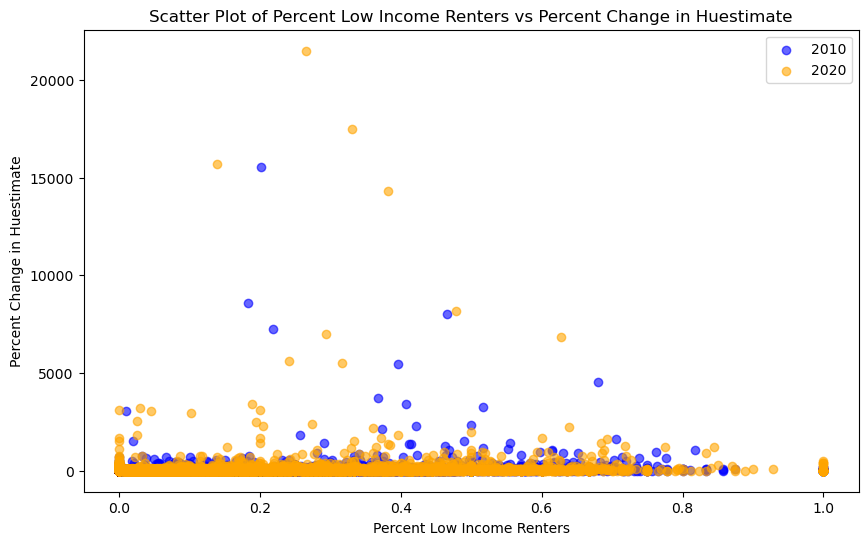

In [53]:
# scatter plot percent low income renters vs percent change in huestimate, colored by year
plt.figure(figsize=(10, 6))
for yr, color in zip(['2010', '2020'], ['blue', 'orange']):
    plt.scatter(
        tabblock_huest_dict_gdf[yr]['percent_low_income_renter'],
        tabblock_huest_dict_gdf[yr]['percent_change'],
        label=yr,
        alpha=0.6,
        color=color
    )
plt.xlabel('Percent Low Income Renters')
plt.ylabel('Percent Change in Huestimate')
plt.title('Scatter Plot of Percent Low Income Renters vs Percent Change in Huestimate')
plt.legend()
plt.show()

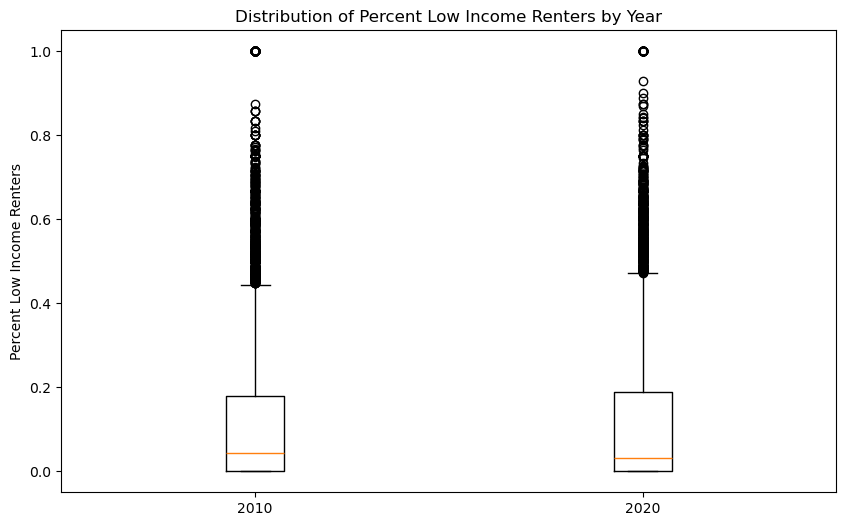

In [54]:
# whisker plot of percent low income renters by year
plt.figure(figsize=(10, 6))
data_2010 = tabblock_huest_dict_gdf['2010']['percent_low_income_renter'].dropna()
data_2020 = tabblock_huest_dict_gdf['2020']['percent_low_income_renter'].dropna()
plt.boxplot([data_2010, data_2020], labels=['2010', '2020'])
plt.title('Distribution of Percent Low Income Renters by Year')
plt.ylabel('Percent Low Income Renters')
plt.show()



In [55]:
condition = sorted_hayward_2010['BLOCKID10_str'] == 'B060014373002012'
sorted_hayward_2010[['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']][condition]

,BLOCKID10_str,placeNAME10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit,numprec,percent_renter,percent_low_income_renter,percent_high_income_homeowner
938,B060014373002012,Hayward,255.0,47.0,117.0,166847.21,2.93617,117.948718,654.302784,754.0,0.99061,0.460094,0.0


In [56]:
checker = BlockValidationChecker(
    hua_gdf=hua_gdf_dict['2010'],
    tabblock_gdf=tabblock_huest_dict_gdf['2010'],
    nsi_gdf=nsi_gdf,
    addpt_df=addpt_df_dict['2010'],
    block_col="blockid",
    block_col_tab="blockid",
    bldg_uniqueid="fd_id_bid",
    addpt_structure_id="strctid",
    addpt_occtype_col="occtype",
    bldg_archetype_col="occtype",
    hua_unit_col="huid",
)

In [57]:
block = 'B060014373002012'
m = checker.plot_three_layer_folium(block)

community = "Hayward_CA_NSI"
output_folder = os.path.join("OutputData", f"{community}", "08_Validation")
output_filename = f'{community}_{block}'
save_path = os.path.join(output_folder, f"{output_filename}.html")
m.save(save_path)

condition = tabblock_huest_dict_gdf['2010']['BLOCKID10_str'] == block
tabblock_huest_dict_gdf['2010'][['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']][condition]


,BLOCKID10_str,placeNAME10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit,numprec,percent_renter,percent_low_income_renter,percent_high_income_homeowner
9631,B060014373002012,Hayward,255.0,47.0,117.0,166847.21,2.93617,117.948718,654.302784,754.0,0.99061,0.460094,0.0


In [ ]:
block = 'B060014377013001'
m = checker.plot_three_layer_folium(block)

community = "Hayward_CA_NSI"
output_folder = os.path.join("OutputData", f"{community}", "08_Validation")
output_filename = f'{community}_{block}'
save_path = os.path.join(output_folder, f"{output_filename}.html")
m.save(save_path)

condition = tabblock_huest_dict_gdf['2010']['BLOCKID10_str'] == block
tabblock_huest_dict_gdf['2010'][['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']][condition]


In [ ]:
block = 'B060014365002019'
m = checker.plot_three_layer_folium(block)

community = "Hayward_CA_NSI"
output_folder = os.path.join("OutputData", f"{community}", "08_Validation")
output_filename = f'{community}_{block}'
save_path = os.path.join(output_folder, f"{output_filename}.html")
m.save(save_path)

condition = tabblock_huest_dict_gdf['2010']['BLOCKID10_str'] == block
tabblock_huest_dict_gdf['2010'][['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']][condition]


In [ ]:
block = 'B060014371011007'
m = checker.plot_three_layer_folium(block)

community = "Hayward_CA_NSI"
output_folder = os.path.join("OutputData", f"{community}", "08_Validation")
output_filename = f'{community}_{block}'
save_path = os.path.join(output_folder, f"{output_filename}.html")
m.save(save_path)

condition = tabblock_huest_dict_gdf['2010']['BLOCKID10_str'] == block
tabblock_huest_dict_gdf['2010'][['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']][condition]


In [ ]:
block = 'B060014372001015'
m = checker.plot_three_layer_folium(block)

community = "Hayward_CA_NSI"
output_folder = os.path.join("OutputData", f"{community}", "08_Validation")
output_filename = f'{community}_{block}'
save_path = os.path.join(output_folder, f"{output_filename}.html")
m.save(save_path)

condition = tabblock_huest_dict_gdf['2010']['BLOCKID10_str'] == block
tabblock_huest_dict_gdf['2010'][['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']][condition]


In [58]:
# 2020
checker = BlockValidationChecker(
    hua_gdf=hua_gdf_dict['2020'],
    tabblock_gdf=tabblock_huest_dict_gdf['2020'],
    nsi_gdf=nsi_gdf,
    addpt_df=addpt_df_dict['2020'],
    block_col="blockid",
    block_col_tab="blockid",
    bldg_uniqueid="fd_id_bid",
    addpt_structure_id="strctid",
    addpt_occtype_col="occtype",
    bldg_archetype_col="occtype",
    hua_unit_col="huid",
)

In [60]:
fd_id_bid = 'nsi-475044410-849VJWM4+2XG-5-3-5-4'
condition = hua_gdf_dict['2020']['fd_id_bid'] == fd_id_bid
hua_gdf_dict['2020'][['huid','fd_id_bid','blockid']][condition]

,huid,fd_id_bid,blockid
402837,B060014373002007H0025,nsi-475044410-849VJWM4+2XG-5-3-5-4,60014373002007
553259,B060014373002007H0047,nsi-475044410-849VJWM4+2XG-5-3-5-4,60014373002007
553261,B060014373002007H0041,nsi-475044410-849VJWM4+2XG-5-3-5-4,60014373002007
615927,B060014373002007H0180,nsi-475044410-849VJWM4+2XG-5-3-5-4,60014373002007
615939,B060014373002007H0192,nsi-475044410-849VJWM4+2XG-5-3-5-4,60014373002007
615943,B060014373002007H0202,nsi-475044410-849VJWM4+2XG-5-3-5-4,60014373002007
615965,B060014373002007H0220,nsi-475044410-849VJWM4+2XG-5-3-5-4,60014373002007


In [61]:
block = 'B060014373002007'
year = '2020'
m = checker.plot_three_layer_folium(block)

community = "Hayward_CA_NSI"
output_folder = os.path.join("OutputData", f"{community}", "08_Validation")
output_filename = f'{community}_{block}_{year}'
save_path = os.path.join(output_folder, f"{output_filename}.html")
m.save(save_path)

condition = tabblock_huest_dict_gdf[year][f'BLOCKID{year[2:4]}_str'] == block
tabblock_huest_dict_gdf[year][[f'BLOCKID{year[2:4]}_str',f'placeNAME{year[2:4]}',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit',
                     'numprec','percent_renter','percent_low_income_renter','percent_high_income_homeowner']][condition]


,BLOCKID20_str,placeNAME20,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit,numprec,percent_renter,percent_low_income_renter,percent_high_income_homeowner
14740,B060014373002007,Hayward,260.0,47.0,117.0,166847.21,3.042553,122.222222,641.720038,892.0,0.957198,0.361868,0.003891
